In [1]:
%run utilities_general.ipynb 
%run utilities_DIRKs_and_PIRKs.ipynb
load_standard_packages()
change_wordir()
import json
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import math

C:\Users\andre\AppData\Local\Temp\ipykernel_27552\1467589274.py:1: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy import interpolate
Could not find cannot import name 'dopri5' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


1.58.0


In [2]:
analysis = "DIRKs"

colors, colours = colourblind_palette("own")

#model = "saadat21"
#model = "ODE_v0"
#model = "ODE_v1"
#model = "new_PSI"
#model = "new_PSII"
#model = "new_b6f"
model = "with_dpsi"
# model = "latest_dev"

m = load_model(model)


succesfully loaded with_dpsi :D


In [3]:
# I like to have light as a derived variable
m.add_algebraic_module(module_name = "Light",
    function = lambda X, PFD: PFD, # X is not used
    compounds = ["PQ"], derived_compounds = ["L"], parameters = ['pfd'])

In [4]:
y0 = get_stst_y0(m)

# DIRK

{'ECS_tot': np.float64(3.5914502337861225),
 'ECS_b': np.float64(7.886772274191922),
 'gH': np.float64(0.12331135632226962),
 'vH': np.float64(0.4428665994920991),
 'ECS_Rsquared': np.float64(0.9876348939729499),
 'P700plus_tot': np.float64(0.07726844016797423),
 'P700_b': np.float64(0.0014722637301006181),
 'k_PSI': np.float64(0.6629153531127283),
 'vPSI': np.float64(0.05122243529842235),
 'P700_Rsquared': np.float64(0.9533337886621204),
 'traces': {'P700': 0.00     0.106237
  0.03     0.100127
  0.06     0.094581
  0.09     0.089541
  0.12     0.084952
             ...   
  29.85    0.000059
  29.88    0.000059
  29.91    0.000058
  29.94    0.000058
  29.97    0.000058
  Length: 1000, dtype: float64,
  'ECS': 0.00     13.032630
  0.03     12.288332
  0.06     11.916727
  0.09     11.742533
  0.12     11.660581
             ...    
  29.85     7.816210
  29.88     7.815040
  29.91     7.813869
  29.94     7.812698
  29.97     7.811527
  Length: 1000, dtype: float64}}

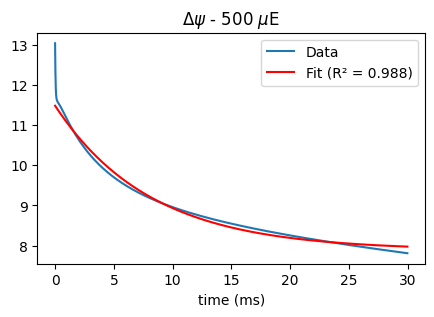

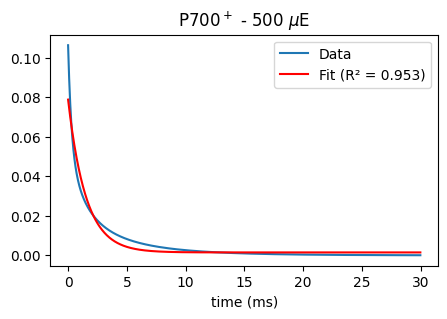

In [5]:
s = Simulator(m)
s.initialise(y0)

pre_relax_time = 0.025
pfd_illum = 500
relax_time = 0.03
relax_pfd = 0
post_relax_time = 0.1

protocol = [[pre_relax_time, pfd_illum],
            [relax_time, relax_pfd],
            [post_relax_time, pfd_illum]
            ]

c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = False, use_tqdm = False, shift_time = False, output_in_ms=False)
# we must not shift time if we wanna analyze it later!

result = analyse_DIRK_from_simulation(c, protocol, input_is_in_ms= False, protocol_time_is_accumulated=False, visualize="all")
# here protocol and c.index have to have the same unit (either ms or s!)

result

## simulate DIRKS with multiple PARS

In [ ]:
pre_relax_time = 0.001
pfd_illum = 50
relax_time = 0.04048 # ECS
relax_time = 0.0408 # P700
relax_pfd = 0
post_relax_time = 0.001 #doesnt matter

protocol = [[pre_relax_time, pfd_illum],
            [relax_time, relax_pfd],
            [post_relax_time, pfd_illum]
            ]

def simulate_DIRK_readouts(PARS, column_translations, visualize= ""):

    out = dict()

    for PAR in tqdm(PARS):
        s = Simulator(m)
        #                                                                       ########################
        #s.update_parameters({"kPCox": 100}) # to make it the limiting step   # CHANGE HERE IF WANTED !!! ############

        protocol[0][1], protocol[2][1] = PAR, PAR
        c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = False, use_tqdm = False, shift_time = False, output_in_ms=False)
        result = analyse_DIRK_from_simulation(c, protocol, input_is_in_ms= False, protocol_time_is_accumulated=False, visualize=visualize, correct_for_amplitude = False)
        result["true_v_PSI"] = v.loc[0, "vPS1"]
        result["true_v_Hp"] = v.loc[0, "vATPsynthase"] + v.loc[0, "vLeak"]
        result["PETC_flux"] = v.loc[0, "vB12"]
        result["vB6f"] = v.loc[0, "vB6f"]
        result["vCyc"] = v.loc[0, "vCyc"]
        result["vPSII"] = v.loc[0, "vB12"]
        result["v4"] = v.loc[0, "v4_to_P700+FA"]
        result["v3"] = v.loc[0, "v3_to_P700FA"]
        result["v2"] = v.loc[0, "v2_to_P700FA-"]
        result["v5"] = v.loc[0, "v5_to_P700FA"]
         
        out[PAR] = result

    df = pd.DataFrame(out).T
    if column_translations:
        df = df.drop(columns = list(set(df.columns) - set(column_translations.keys()))) # get rid of everything else
        df = df.rename(columns= column_translations)
    df['PAR'] = df.index
    return df

In [7]:
PARS = np.linspace(30,1750,20)

simulated = simulate_DIRK_readouts(PARS, None)

100%|██████████| 20/20 [00:57<00:00,  2.85s/it]


In [14]:
simulated

,ECS_tot,ECS_b,gH,vH,ECS_Rsquared,P700plus_tot,P700_b,k_PSI,vPSI,P700_Rsquared,...,true_v_Hp,PETC_flux,vB6f,vCyc,vPSII,v4,v3,v2,v5,PAR
30.000000,0.378659,9.944769,0.051145,0.019367,0.994531,0.039178,0.000023,0.373562,0.014635,0.999977,...,20.914301,22.965604,18.637456,7.856563,22.965604,37.174025,0.011624,0.096811,37.178102,30.000000
120.526316,0.828762,6.663506,0.045688,0.037865,0.996394,0.150236,-0.000001,0.348416,0.052344,0.999992,...,76.154879,95.917674,64.849788,17.551652,95.917674,129.158153,0.395011,0.517538,129.182039,120.526316
211.052632,1.199054,5.912573,0.047905,0.057441,0.996066,0.255237,-0.000157,0.335553,0.085646,0.999926,...,122.011279,155.529992,103.44619,26.417249,155.529992,205.662812,1.015209,1.172254,205.720126,211.052632
301.578947,1.489438,5.516605,0.050014,0.074492,0.995663,0.347553,-0.000358,0.327523,0.113832,0.999835,...,159.315943,203.883029,134.880093,33.743617,203.883029,267.640967,1.831773,2.016661,267.743525,301.578947
392.105263,1.722222,5.28826,0.051952,0.089472,0.995271,0.426144,-0.000564,0.322082,0.137253,0.999748,...,189.458916,242.902482,160.29197,39.703841,242.902482,317.39198,2.824559,3.033286,317.550653,392.105263
482.631579,1.911643,5.153337,0.053727,0.102708,0.994909,0.49209,-0.000755,0.318241,0.156603,0.99967,...,213.842657,274.460192,180.85013,44.531548,274.460192,357.254892,3.989395,4.219956,357.480303,482.631579
573.157895,2.068042,5.074537,0.055355,0.114476,0.994577,0.547172,-0.000927,0.315425,0.172592,0.999605,...,233.686434,300.161151,197.575832,48.447304,300.161151,389.259877,5.336562,5.588504,389.56316,573.157895
663.684211,2.199153,5.030798,0.056841,0.125003,0.994271,0.593245,-0.001078,0.313315,0.185873,0.999551,...,249.97569,321.295342,211.296278,51.634896,321.295342,415.034765,6.890047,7.16419,415.428366,663.684211
754.210526,2.310563,5.009679,0.058205,0.134487,0.993991,0.631939,-0.001209,0.3117,0.196975,0.999505,...,263.477739,338.865817,222.655912,54.238499,338.865817,435.827191,8.687832,8.986128,436.325696,754.210526
844.736842,2.406471,5.003283,0.059455,0.143077,0.993735,0.66463,-0.001323,0.310448,0.206333,0.999467,...,274.779716,353.641578,232.147478,56.367326,353.641578,452.564935,10.783435,11.10895,453.186005,844.736842


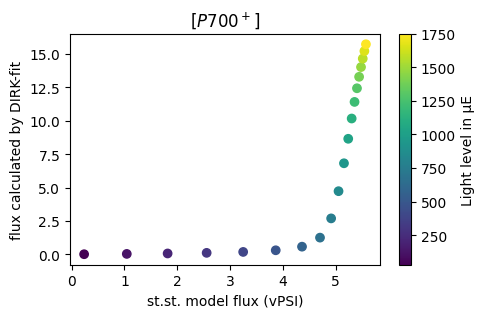

In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize=(5,3))

cmap = plt.cm.viridis
norm = plt.Normalize(simulated.PAR.min(), simulated.PAR.max())

sc1 = ax1.scatter(simulated.true_v_Hp - simulated.vB6f, simulated.vH, c=simulated.PAR, cmap=cmap, norm=norm)
ax1.set(
    xlabel = "st.st. model flux (???)",
    title = "$????$",
    ylabel = "flux calculated by DIRK-fit",
    # xlim=(150,200),
    # ylim=(80,90)
    #yscale = "log"
)

cbar = fig.colorbar(sc1, ax=ax1, label="Light level in µE")

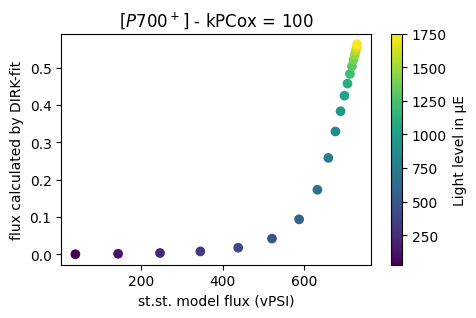

In [13]:
fig, ax1 = plt.subplots(1, 1, figsize=(5,3))

cmap = plt.cm.viridis
norm = plt.Normalize(simulated.PAR.min(), simulated.PAR.max())

sc1 = ax1.scatter(simulated.true_v_PSI, simulated.vPSI, c=simulated.PAR, cmap=cmap, norm=norm)
ax1.set(
    xlabel = "st.st. model flux (vPSI)",
    title = "$[P700^+$] - kPCox = 100",
    ylabel = "flux calculated by DIRK-fit"
)

cbar = fig.colorbar(sc1, ax=ax1, label="Light level in µE")


In [20]:
save_fig(fig, "in_silico", ".", f"model_and_inferred_fit_kPCox100")

saved figure to figures/in_silico/./model_and_inferred_fit_kPCox100.png


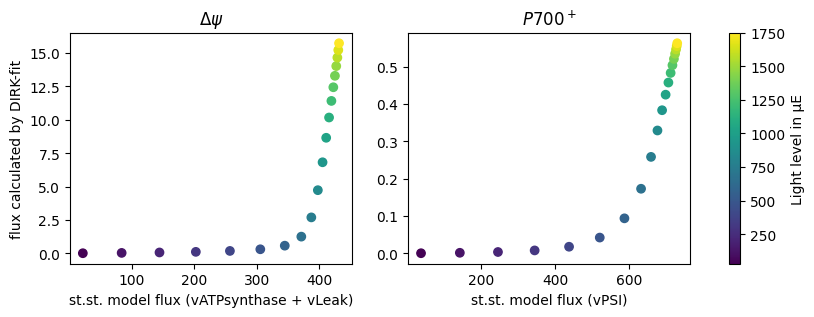

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,3))

cmap = plt.cm.viridis
norm = plt.Normalize(simulated.PAR.min(), simulated.PAR.max())

sc1 = ax1.scatter(simulated.true_v_Hp, simulated.vH, c=simulated.PAR, cmap=cmap, norm=norm)
ax1.set(#yscale= "log",
        xlabel = "st.st. model flux (vATPsynthase + vLeak)",
        title = "$\Delta \psi$",
        ylabel = "flux calculated by DIRK-fit")
sc2 = ax2.scatter(simulated.true_v_PSI, simulated.vPSI, c=simulated.PAR, cmap=cmap, norm=norm)
ax2.set(#yscale= "log",
        xlabel = "st.st. model flux (vPSI)",
        title = "$P700^+$",
        #ylabel = "flux calculated DIRK fit"
        )

cbar = fig.colorbar(sc1, ax=[ax1, ax2], label="Light level in µE")

In [9]:
save_fig(fig, "in_silico", ".", f"model_and_inferred_fit")

existing figure backed up to figures/in_silico/./Z_backup_model_and_inferred_fit.png
saved figure to figures/in_silico/./model_and_inferred_fit.png


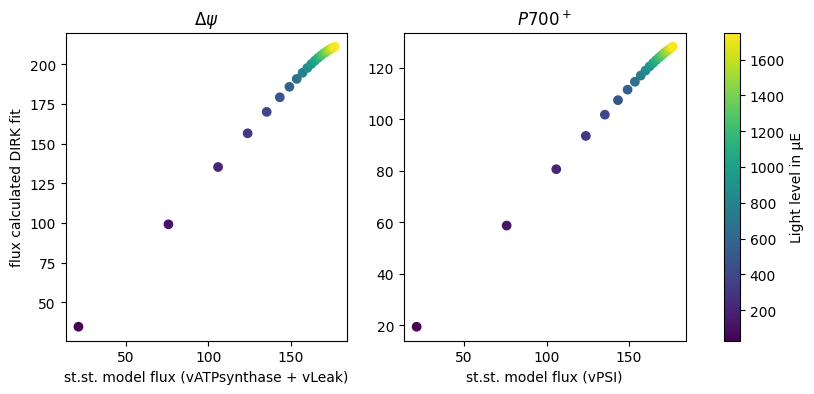

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

cmap = plt.cm.viridis
norm = plt.Normalize(simulated.PAR.min(), simulated.PAR.max())

sc1 = ax1.scatter(simulated.PETC_flux, simulated.true_v_PSI, c=simulated.PAR, cmap=cmap, norm=norm)
ax1.set(#yscale= "log",
        xlabel = "st.st. model flux (vATPsynthase + vLeak)",
        title = "$\Delta \psi$",
        ylabel = "flux calculated DIRK fit")
sc2 = ax2.scatter(simulated.PETC_flux, simulated.true_v_Hp, c=simulated.PAR, cmap=cmap, norm=norm)
ax2.set(#yscale= "log",
        xlabel = "st.st. model flux (vPSI)",
        title = "$P700^+$",
        #ylabel = "flux calculated DIRK fit"
        )

cbar = fig.colorbar(sc1, ax=[ax1, ax2], label="Light level in µE")

In [13]:
## Redefine fit function to make lines wider:

def fit_function(x, y, model_func, p0, bounds=None, visualize: Union[str, float] = "", title=""):
    try:
        if bounds is None:
            inf = np.inf
            bounds = ([-inf] * len(p0), [inf] * len(p0))

        p_opt, p_cov = curve_fit(model_func, x, y,
                                p0=p0,
                                bounds=bounds,
                                maxfev=10000)

        fitted_curve = model_func(x, *p_opt)

        # R² calculation
        residuals = y - fitted_curve
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        R2 = 1 - (ss_res / ss_tot)

        if visualize == "all" or isinstance(visualize, float):
            cutoff = 1 if visualize == "all" else visualize
            if R2 <= cutoff:
                fig, ax = plt.subplots(figsize=(5, 3))
                ax.set(title=title, xlabel="time (ms)")
                ax.plot(x, y, label='Data', linewidth = 2.5)
                ax.plot(x, fitted_curve, color='red', label=f'Fit (R² = {R2:.3f})', linewidth = 2.5)
                ax.legend()
                fig.show()

        out = list(p_opt) + [R2]

    except Exception as e:
        out = [np.nan] * (len(p0) + 1)
        raise RuntimeError(f"Error in fitting: {e}")

    return out

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:12<00:00,  3.11s/it]


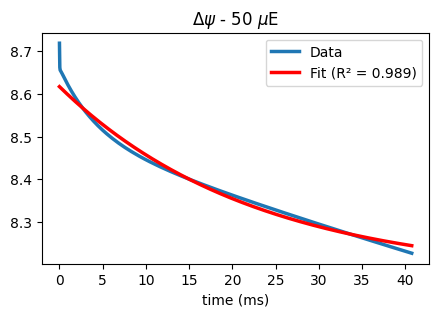

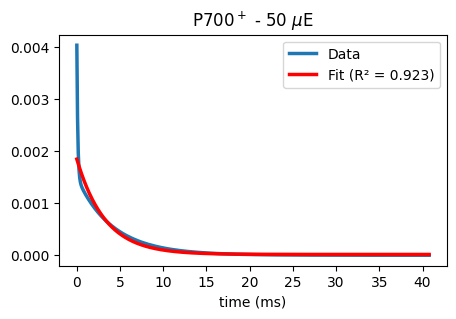

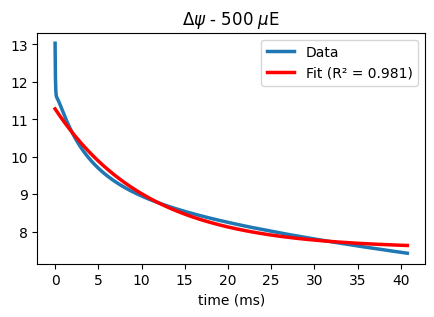

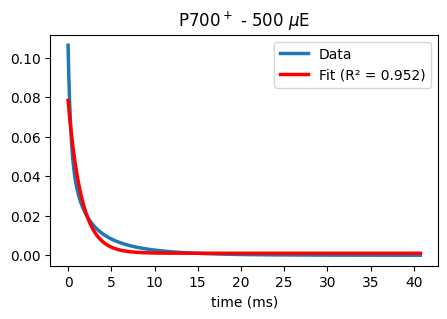

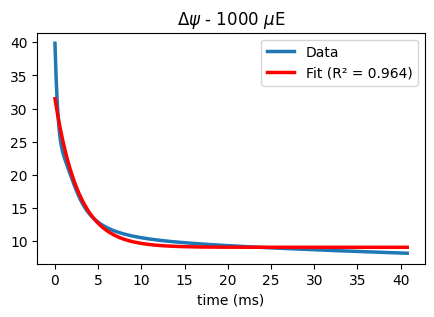

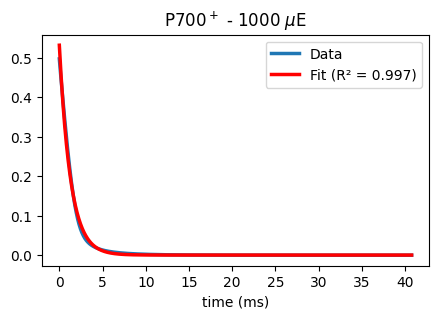

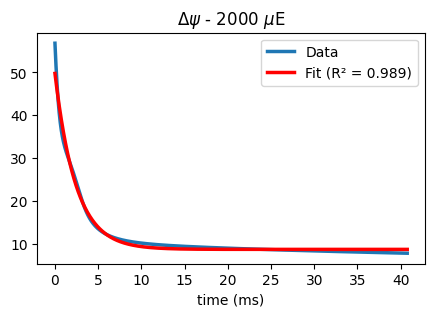

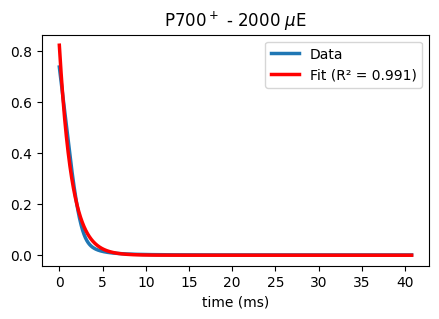

In [14]:
PARS = (50, 500, 1000, 2000)
simulated = simulate_DIRK_readouts(PARS, None, "all")